In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
df=pd.read_excel(r'C:\Users\HP\Downloads\DATASETS\weather data.xlsx')
df

,date,amount_of_precipitation,max_temperature,min_temperature,rainfall
0,1948-01-01,0.47,51,42,0.0
1,1948-01-02,0.59,45,36,0.0
2,1948-01-03,0.42,45,35,0.0
3,1948-01-04,0.31,45,34,0.0
4,1948-01-05,0.17,45,32,0.0
...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,0.0
25547,2017-12-11,0.00,49,29,0.0
25548,2017-12-12,0.00,46,32,0.0
25549,2017-12-13,0.00,48,34,0.0


In [3]:
#checking for missing values
df.isnull().sum()

date                       0
amount_of_precipitation    3
max_temperature            0
min_temperature            0
rainfall                   3
dtype: int64

# **Data Cleaning and Feature Engineering**

## Data Cleaning

In [4]:
columns=['date', 'amount_of_precipitation', 'max_temperature', 'min_temperature', 'rainfall']
df=df.drop_duplicates(columns).dropna()
df['rainfall']= df.rainfall.astype(int)
df.shape

(25546, 5)

## Feature Engineering

In [5]:
#Converting the date column to date-time format
df['date'] = pd.to_datetime(df.date)

# Feature extraction for year, month and decade columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['decade'] = (df['year'] // 10) * 10

# This is to create a column for the average daily temperature for each of the days 
df['average_daily_temperature']=(df['min_temperature']+df['max_temperature'])/2


In [6]:
df.describe()

,date,amount_of_precipitation,max_temperature,min_temperature,rainfall,year,month,decade,average_daily_temperature
count,25546,25546.000000,25546.000000,25546.000000,25546.000000,25546.000000,25546.000000,25546.000000,25546.000000
mean,1982-12-21 16:31:11.447584704,0.106230,59.542512,44.512761,0.426251,1982.473107,6.519064,1977.975417,52.027636
min,1948-01-01 00:00:00,0.000000,4.000000,0.000000,0.000000,1948.000000,1.000000,1940.000000,10.000000
25%,1965-06-26 06:00:00,0.000000,50.000000,38.000000,0.000000,1965.000000,4.000000,1960.000000,44.125000
50%,1982-12-20 12:00:00,0.000000,58.000000,45.000000,0.000000,1982.000000,7.000000,1980.000000,51.500000
75%,2000-06-17 18:00:00,0.100000,69.000000,52.000000,1.000000,2000.000000,10.000000,2000.000000,60.500000
max,2017-12-14 00:00:00,5.020000,103.000000,71.000000,1.000000,2017.000000,12.000000,2010.000000,87.000000
std,NaN,0.239039,12.773487,8.893085,0.494541,20.193387,3.447309,20.387601,10.461706


# **Exploratory Analysis**
### Analysis on Seasonal Patterns and Global warming indicators

In [7]:
monthly_avg = df.groupby('month')[['amount_of_precipitation', 'max_temperature', 'min_temperature', 'average_daily_temperature']].mean()
decade_avg = df.groupby('decade')[['amount_of_precipitation', 'max_temperature', 'min_temperature', 'average_daily_temperature']].mean()
yearly_avg = df.groupby('year')[['amount_of_precipitation', 'max_temperature', 'min_temperature', 'average_daily_temperature']].mean()

The code above is to calculate the average weather conditions over different time periods. 
It groups the data by month to analyze seasonal trends and by decade to observe long-term climate changes. 
This is to help understand how precipitation and temperatures vary over time.

### **Seasonal Patterns Trend Analysis**

The goal of this monthly temperature analysis is to understand how temperatures change throughout the year and spot seasonal trends. I want to investigate which months are the hottest and coldest and I’m also looking at how the seasons transition month by month

In [8]:
#This is to show the average weather conditions for each of the months over the years from 1948 to 2017
monthly_avg

,amount_of_precipitation,max_temperature,min_temperature,average_daily_temperature
month,,,,
1,0.183055,45.131797,35.208756,40.170276
2,0.143023,48.994944,36.787664,42.891304
3,0.127963,52.321659,38.393548,45.357604
4,0.088505,57.521905,41.460952,49.491429
5,0.058502,64.309217,46.733180,55.521198
6,0.048546,69.658560,51.628040,60.643300
7,0.023106,75.497696,55.005530,65.251613
8,0.034968,75.233180,55.317512,65.275346
9,0.059085,69.630124,51.754051,60.692088


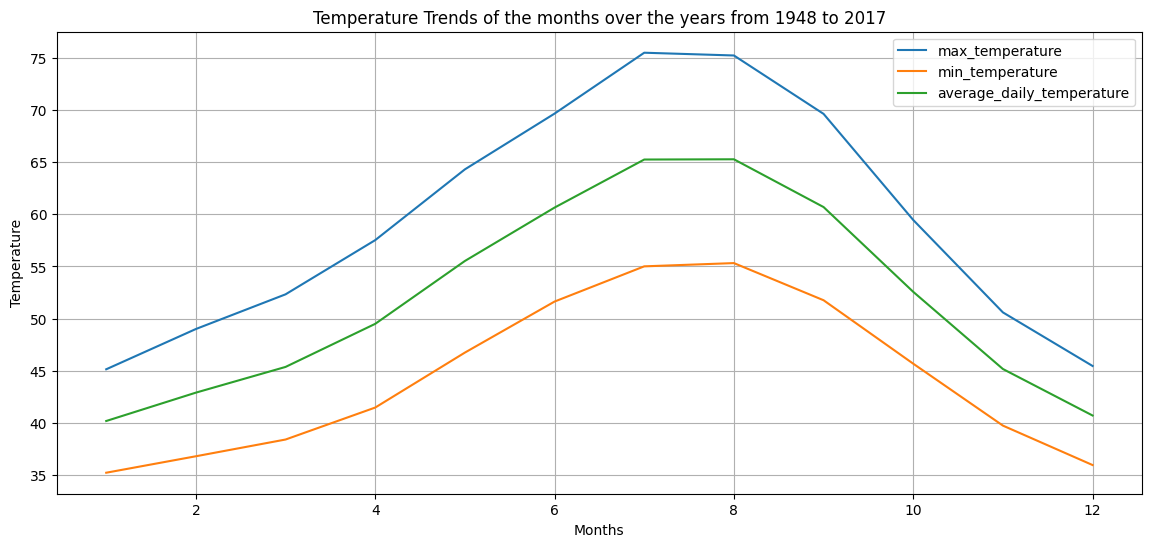

In [9]:
plt.figure(figsize=(14, 6))

for i in ['max_temperature', 'min_temperature', 'average_daily_temperature']:
    plt.plot(monthly_avg.index, monthly_avg[i], label=i)

plt.title('Temperature Trends of the months over the years from 1948 to 2017')
plt.xlabel('Months')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

From the analysis and visualization above, the insights derived are as follows:

❄️ From December to February, the temperatures seem to be at their lowest implying that these are the coldest months, all making up Winter season, with January & December at the lowest temperatures, but February sees a slight warm-up as spring approaches.

🌸 From March to May, a steady temperature rise begins and here, Spring begins. Temperatures at March are mild, April gets warmer, and May signals summer’s arrival with noticeably higher max and min temperatures.

☀️ July and August are the hottest months, with temperatures reaching their peaks at these months. July and August experience their peak of heat before temperatures begin to drop while transitioning into Autumn. It is between the months of July to August we usually enjoy the summer holidays 

🍂 from September to November, a gradual cooldown occurs as temperatures begin to drop. September and October remain warm, but by November, temperatures drop sharply, marking the transition back to winter. September to November is usually when we have Autumn

### **Global Warming and Climate change Indicator**
This temperature trend analysis over the decades aims to examine how temperature patterns have changed from the 1940s to the 2010s, identify long-term warming trends, showing that both maximum and minimum temperatures have generally increased over the decades and spotting any anomalies or slowdowns in temperature rise.

In [10]:
#This is to show the average weather conditions over the decades from 1948 to 2017
decade_avg = df.groupby('decade')[['max_temperature', 'min_temperature', 'amount_of_precipitation', 'average_daily_temperature']].mean()
decade_avg

,max_temperature,min_temperature,amount_of_precipitation,average_daily_temperature
decade,,,,
1940,58.079343,41.294118,0.107045,49.686731
1950,58.089540,42.425246,0.114225,50.257393
1960,59.285245,44.314810,0.106463,51.800027
1970,59.354053,44.679080,0.101906,52.016566
1980,59.611826,44.579524,0.095623,52.095675
1990,60.421485,45.294601,0.109419,52.858043
2000,59.586141,44.958368,0.099271,52.272254
2010,61.051635,46.360757,0.119194,53.706196


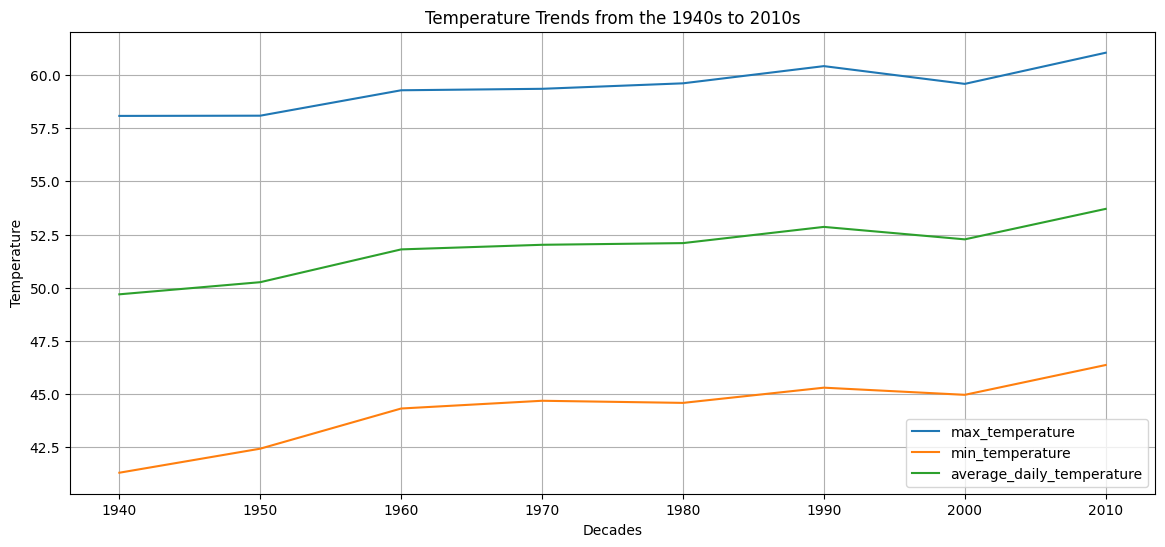

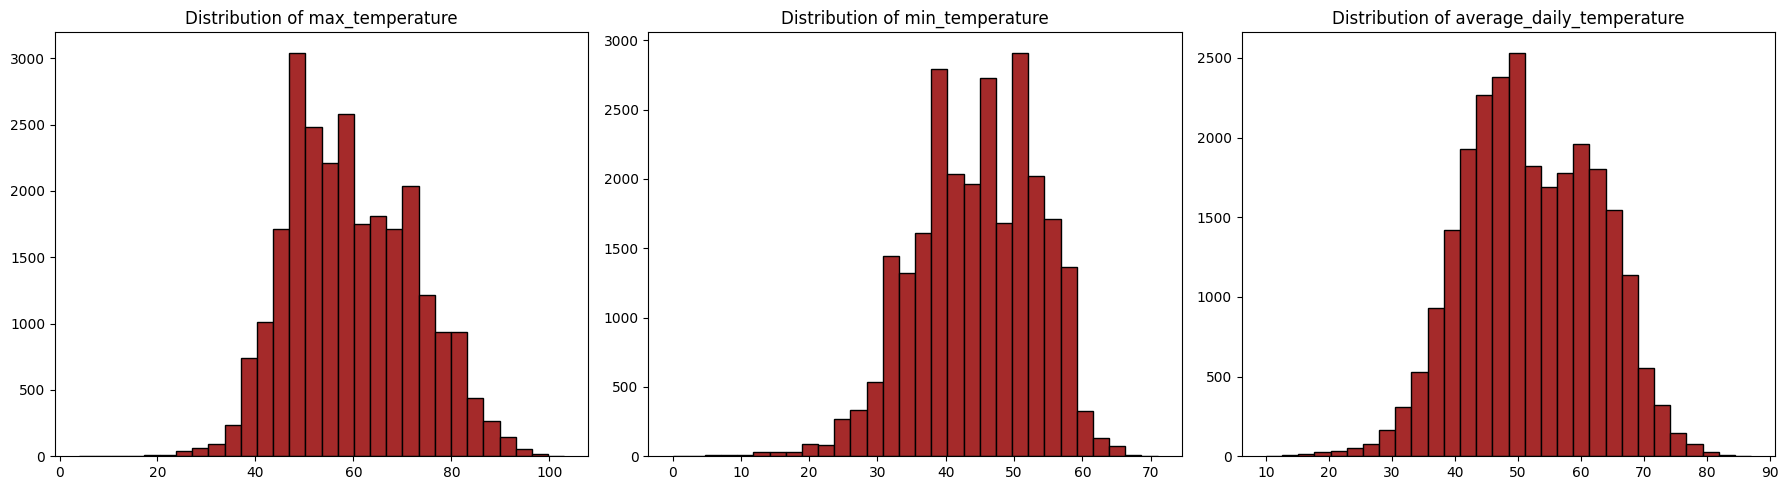

In [11]:
plt.figure(figsize=(14, 6))

for i in ['max_temperature', 'min_temperature', 'average_daily_temperature']:
    plt.plot(decade_avg.index, decade_avg[i], label=i)

plt.title('Temperature Trends from the 1940s to 2010s')
plt.xlabel('Decades')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

#histogram for all temperature distributions in separate subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # a 1-row, 3-column layout

for ax, i in zip(axes, ['max_temperature', 'min_temperature', 'average_daily_temperature']):
    ax.hist(df[i], bins=30, color='brown', edgecolor='black')
    ax.set_title(f'Distribution of {i}')

plt.tight_layout() 
plt.show()

Here are major takeaways on the decadal temperature analysis that I carried out above:

- To start with, we're seeing a clear, long-term increase in temperatures across the chart. This is a big red flag for climate change and a major indicator of gloabal warming.

- The coolest temperatures we experience during the nights are climbing more rapidly than the hottest daytime temperatures. This is a problem because it means there is less relief from the heat of the daytime.

The implications of these observations will be that:

1. Because nights are getting waermer there will be stress on plants and animals that need those cooler nighttime hours.

2. There will be more frequent and intense heat waves which pose danger to our health, especially for the elderly and vulnerable.

3. Changes in temperature will also lead to shifts in rainfall and precipitations, impacting everything from farming to water supply.

4. Ecosystems will being disrupted, affecting how plants and animals live and move.
5. The extra heat will cause oceans to expand and glaciers to melt, contributing to rising sea levels.

## **Precipitation Trends and Insights**

### Decadal Precipitation Trend 

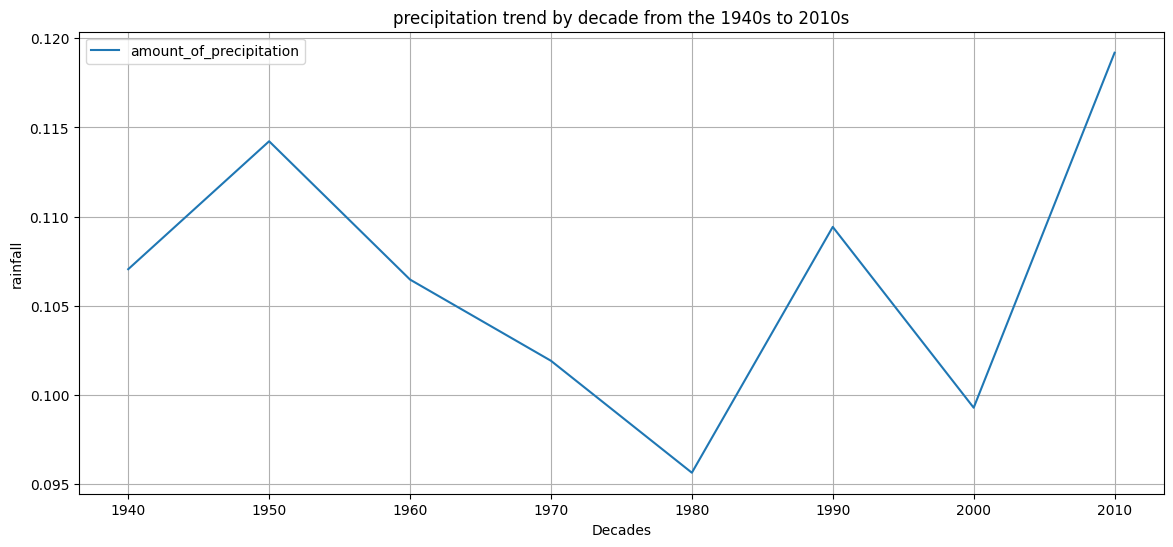

In [12]:
# Here I want to visualize and try to understand the precipitation trend over the decades from the 1940s

plt.figure(figsize=(14, 6))
plt.plot(decade_avg.index, decade_avg['amount_of_precipitation'], label='amount_of_precipitation')
plt.title('precipitation trend by decade from the 1940s to 2010s')
plt.xlabel('Decades')
plt.ylabel('rainfall')
plt.legend()
plt.grid(True)
plt.show()

The rainfall chart shows a cyclical pattern from the 1940s to 2010s. After reaching a high point around the 1950s (0.114), rainfall dropped steadily until its lowest level in the 1980s (0.096). It rose again in the 1990s (0.109) and dipped slightly in the 2000s before climbing sharply to its highest level by the 2010s (0.119). The periods of falling rainfall likely mean drier weather caused by natural changes in climate, possible dry spells in the region, or changing weather patterns. The sharp rise from the 2000s to 2010s is the most dramatic change in the chart, which might show that the water cycle is becoming more intense due to more considerable weather and climate changes.

### Precipitation Trend by Months 

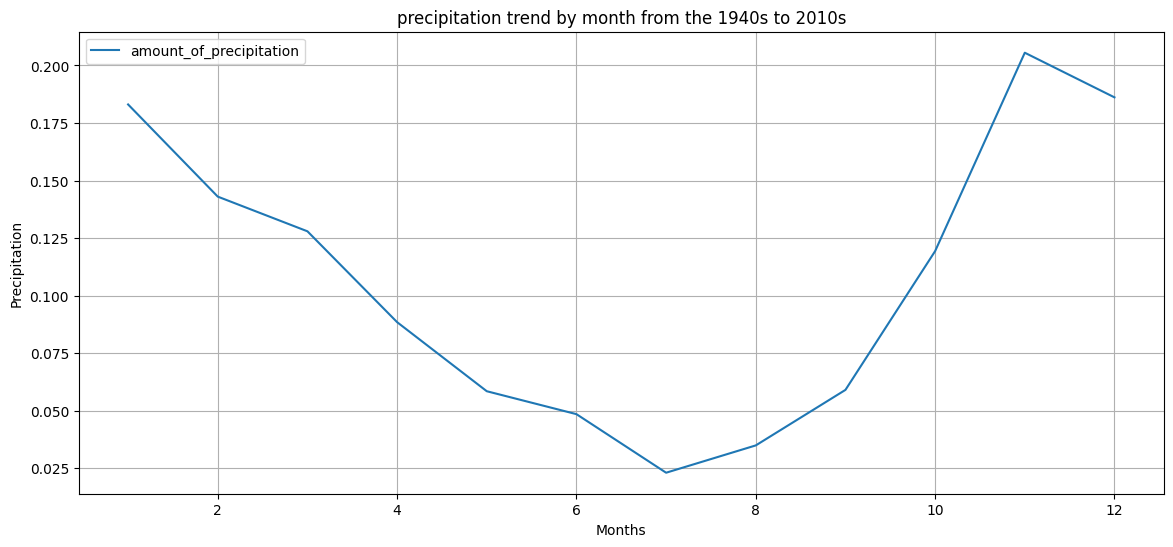

In [16]:
# Here I want to visualize and try to understand the precipitation trend for months from the 1940s

plt.figure(figsize=(14, 6))
plt.plot(monthly_avg.index, monthly_avg['amount_of_precipitation'], label='amount_of_precipitation')
plt.title('precipitation trend by month from the 1940s to 2010s')
plt.xlabel('Months')
plt.ylabel('Precipitation')
plt.legend()
plt.grid(True)
plt.show()

The rainfall data shows a clear yearly pattern, with the wettest time in November (around 0.2), followed closely by December and January (around 0.18). From there, the rain gradually decreases through spring (March-May) until reaching its lowest point in July (around 0.02) during the summer. Rainfall then slowly builds back up during fall (September-October). This pattern matches what we typically expect in temperate climates, where winters bring more rain or snow, summers stay relatively dry with occasional storms, and spring and fall serve as transition periods with moderate rainfall. The line graph with its gridlines displays these seasonal changes, making it easy to spot when the wet and dry periods occur throughout the year

# Identifying extreme events

In [ ]:

extremes = {
    'Highest Max Temp': df.nlargest(5, 'max_temperature')[['date', 'max_temperature']],
    'Lowest Min Temp': df.nsmallest(5, 'min_temperature')[['date', 'min_temperature']],
    'Highest Precipitation': df.nlargest(5, 'amount_of_precipitation')[['date', 'amount_of_precipitation']]
}
# the results
for event, data in extremes.items():
    print(f"{event}:")
    print(data)
    print("\n")

Highest Max Temp:
            date  max_temperature
22490 2009-07-29              103
17002 1994-07-20              100
4604  1960-08-09               99
12274 1981-08-09               99
15909 1991-07-23               99


Lowest Min Temp:
           date  min_temperature
761  1950-01-31                0
762  1950-02-01                1
1152 1951-02-26                2
732  1950-01-02                6
733  1950-01-03                6


Highest Precipitation:
            date  amount_of_precipitation
20381 2003-10-20                     5.02
21886 2007-12-03                     3.77
4341  1959-11-20                     3.41
21494 2006-11-06                     3.29
17570 1996-02-08                     3.06




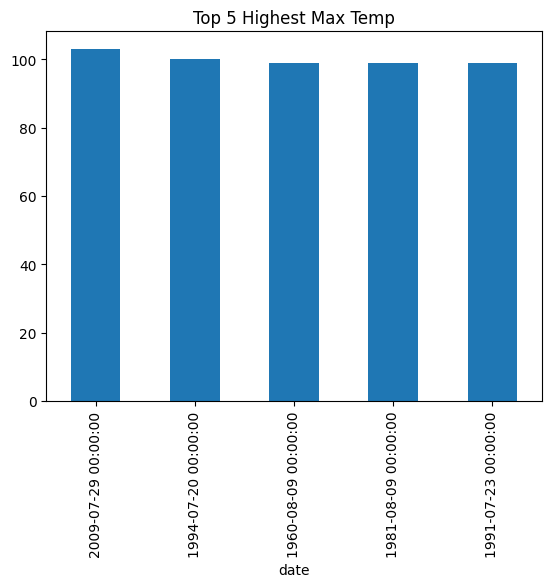

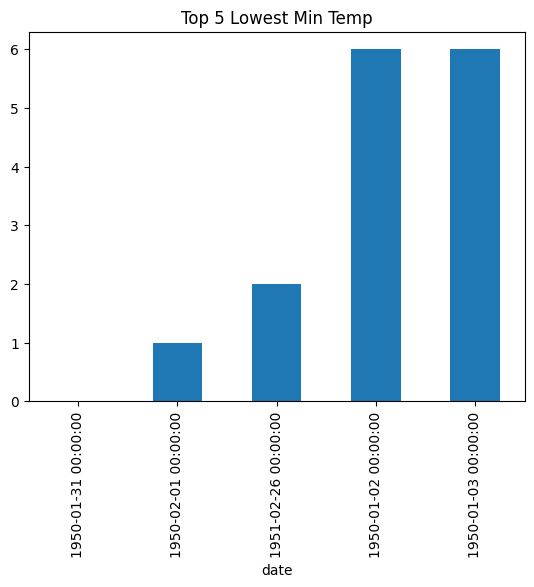

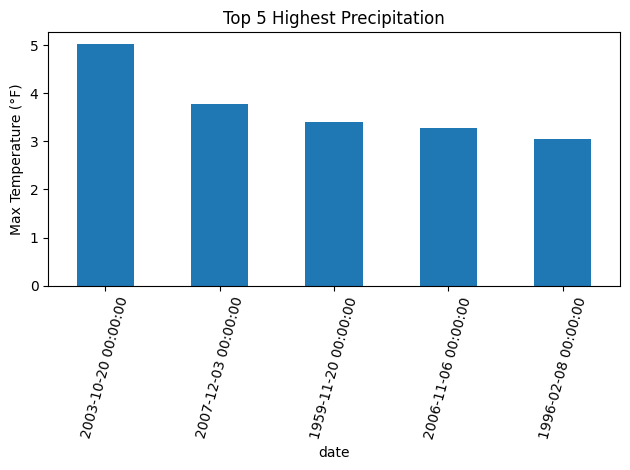

In [15]:
Extremes=[('Highest Max Temp','max_temperature'), ('Lowest Min Temp', 'min_temperature'), ('Highest Precipitation', 'amount_of_precipitation')]
for i,j in Extremes: 
    # Bar charts fro extremes 
    extremes[i].plot(x='date', y=j, kind='bar', title=f'Top 5 {i}', legend=False)
plt.ylabel("Max Temperature (°F)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



# **Conclusion**
This Exploratory Data Analysis (EDA) reveals a consistent warming trend over the decades, with maximum, minimum, and average daily temperatures showing a clear upward trajectory from the 1940s to the 2010s. The steady rise in both daytime highs and nighttime lows provides strong evidence of long-term climate change rather than short-term variability. Even though the trend is generally upward, irregular variations, like modest temperature drops in the 2000s, point to the possibility of decadal variations that geographic or environmental factors may have influenced. Significantly, warmer nights and shorter cooling periods, two important signs of a changing climate, are indicated by the increase in minimum temperatures. This study identifies a significant warming trend supporting ongoing discussions about climate change. It offers valuable data to planners, environmentalists, and legislators working to slow down and prepare for a warming world.